In [99]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [100]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

kernel_diamond = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
], dtype=np.uint8)

kernel_cross = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
], dtype=np.uint8)

kernel_x = np.array([
    [1,0,0,0,1],
    [0,1,0,1,0],
    [0,0,1,0,0],
    [0,1,0,1,0],
    [1,0,0,0,1]
], dtype=np.uint8)

tigaXtiga = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32)

limaXlima = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype=np.float32)

In [101]:
def konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

In [102]:
def edge(img, kernelx, kernely):
    gx = konvolusi(img, kernelx)
    gy = konvolusi(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

In [103]:
def resize(image, new_width, new_height):
    """
    Resize — ubah ukuran citra.
    Contoh: hasil = fungsi_dua(citra, 256, 256)
    """
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

In [104]:
def threshold(img, batas): 
    baris, kolom = img.shape 
    canvas = np.zeros_like(img, dtype=np.uint8) 
    for i in range(baris): 
        for j in range(kolom): 
            if(img[i,j] > batas): 
                canvas[i,j] = 255 
            elif(img[i,j] <= batas): 
                canvas[i,j] = 0 
    return canvas

In [105]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil

In [106]:
def erosi(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape
    
    center_y = k_height // 2
    center_x = k_width // 2
    
    hasil = np.zeros((img_height, img_width), dtype=np.uint8)
    
    for i in range(img_height):
        for j in range(img_width):
            
            cocok = True
            
            for k in range(k_height):
                for l in range(k_width):
                    
                    img_i = i + k - center_y
                    img_j = j + l - center_x
                    
                    if kernel[k, l] == 1:
                        if (img_i < 0 or img_i >= img_height or 
                            img_j < 0 or img_j >= img_width):
                            cocok = False
                            break
                        
                        if image[img_i, img_j] == 0:
                            cocok = False
                            break
                if not cocok:
                    break
            
            if cocok:
                hasil[i, j] = 255
                
    return hasil

In [107]:
def thinning(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape
    
    center_y = k_height // 2
    center_x = k_width // 2
    
    hasil = np.zeros((img_height, img_width), dtype=np.uint8)
    
    for i in range(img_height):
        for j in range(img_width):
            
            cocok = True
            
            for k in range(k_height):
                for l in range(k_width):
                    
                    img_i = i + k - center_y
                    img_j = j + l - center_x
                    
                    if kernel[k, l] == 1:
                        if (img_i < 0 or img_i >= img_height or 
                            img_j < 0 or img_j >= img_width):
                            cocok = False
                            break
                        
                        if image[img_i, img_j] == 0:
                            cocok = False
                            break
                if not cocok:
                    break
            
            if cocok:
                hasil[i, j] = 255
                
    return hasil

In [108]:
def thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = dilasi(hasil, kernel) 
    return hasil

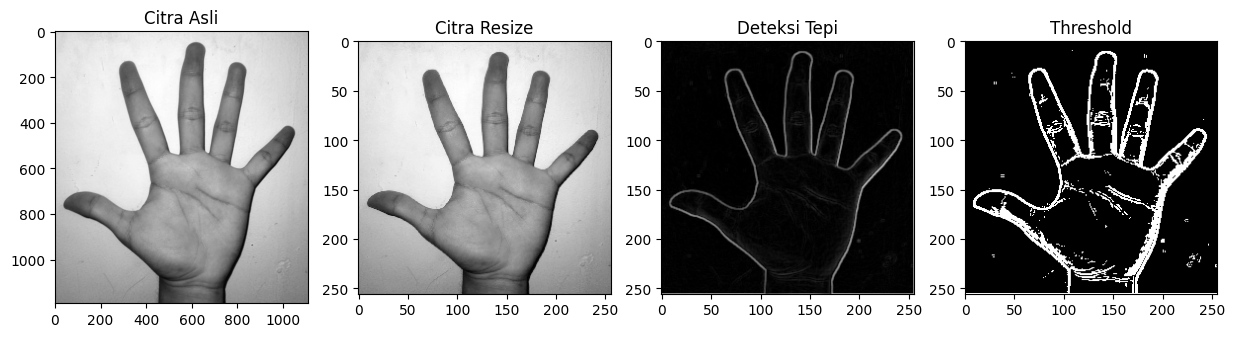

In [115]:
tangan = cv2.imread('tangan.jpeg')

tangan_gray = cv2.cvtColor(tangan, cv2.COLOR_BGR2GRAY)

tangan_resize = resize(tangan_gray, 256, 256)

tangan_sobel = edge(tangan_resize, prewittX, prewittY)

tangan_threshold = threshold(tangan_sobel, 15)

plt.figure(figsize=(15, 10))

plt.subplot(1,4,1)
plt.imshow(tangan_gray, cmap='gray')
plt.title('Citra Asli')

plt.subplot(1,4,2)
plt.imshow(tangan_resize, cmap='gray')
plt.title('Citra Resize')

plt.subplot(1,4,3)
plt.imshow(tangan_sobel, cmap='gray')
plt.title('Deteksi Tepi')

plt.subplot(1,4,4)
plt.imshow(tangan_threshold, cmap='gray')
plt.title('Threshold')

plt.show()

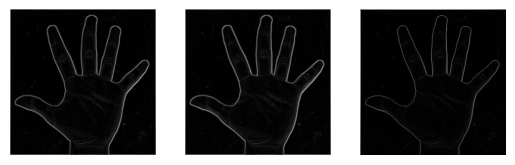

In [118]:
tangan_sobel = edge(tangan_resize, sobelX, sobelY)
tangan_prewitt = edge(tangan_resize, prewittX, prewittY)
tangan_roberts = edge(tangan_resize, robertsX, robertsY)

plt.subplot(1,3,1)
plt.imshow(tangan_sobel, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(tangan_prewitt, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(tangan_roberts, cmap='gray')
plt.axis('off')

plt.show()

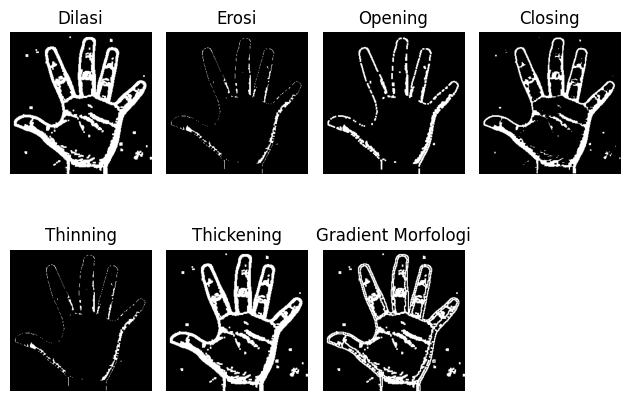

In [ ]:
tangan_dilasi = dilasi(tangan_threshold, tigaXtiga)
tangan_erosi = erosi(tangan_threshold, tigaXtiga)
tangan_opening = dilasi(erosi(tangan_threshold, tigaXtiga), tigaXtiga)
tangan_closing = erosi(dilasi(tangan_threshold, tigaXtiga), tigaXtiga)
tangan_thinning = thinning(tangan_threshold, tigaXtiga)
tangan_thickening = thickening(tangan_threshold, tigaXtiga)
tangan_gradient_morph = np.clip(
    tangan_dilasi.astype(np.int32) - tangan_erosi.astype(np.int32),
    0,
    255
).astype(np.uint8)

plt.subplot(2,4, 1)
plt.imshow(tangan_dilasi, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4, 2)
plt.imshow(tangan_erosi, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4, 3)
plt.imshow(tangan_opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4, 4)
plt.imshow(tangan_closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4, 5)
plt.imshow(tangan_thinning, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4, 6)
plt.imshow(tangan_thickening, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4, 7)
plt.imshow(tangan_gradient_morph, cmap='gray')
plt.title('Gradient Morfologi')
plt.axis('off')
plt.tight_layout()

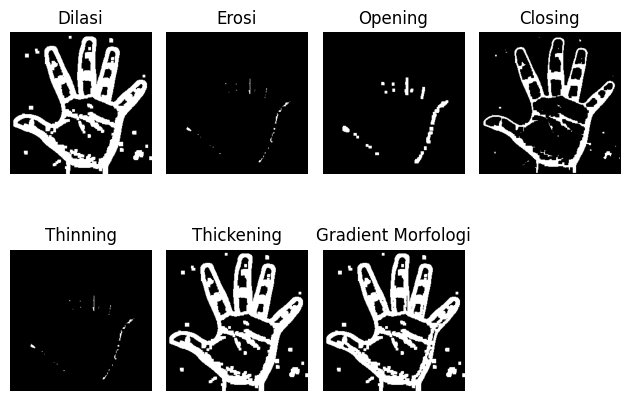

In [112]:


tangan_dilasi = dilasi(tangan_threshold, limaXlima)
tangan_erosi = erosi(tangan_threshold, limaXlima)
tangan_opening = dilasi(erosi(tangan_threshold, limaXlima), limaXlima)
tangan_closing = erosi(dilasi(tangan_threshold, limaXlima), limaXlima)
tangan_thinning = thinning(tangan_threshold, limaXlima)
tangan_thickening = thickening(tangan_threshold, limaXlima)
tangan_gradient_morph = np.clip(
    tangan_dilasi.astype(np.int32) - tangan_erosi.astype(np.int32),
    0,
    255
).astype(np.uint8)

plt.subplot(2,4, 1)
plt.imshow(tangan_dilasi, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4, 2)
plt.imshow(tangan_erosi, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4, 3)
plt.imshow(tangan_opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4, 4)
plt.imshow(tangan_closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4, 5)
plt.imshow(tangan_thinning, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4, 6)
plt.imshow(tangan_thickening, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4, 7)
plt.imshow(tangan_gradient_morph, cmap='gray')
plt.title('Gradient Morfologi')
plt.axis('off')
plt.tight_layout()

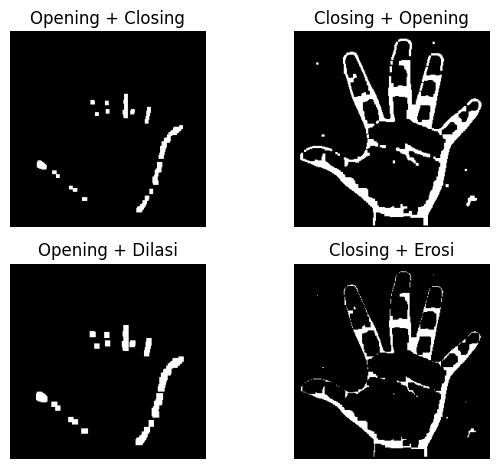

In [117]:
tangan_openclose = erosi(dilasi(tangan_opening, tigaXtiga), tigaXtiga)
tangan_closeopen = dilasi(erosi(tangan_closing, tigaXtiga), tigaXtiga)
tangan_opendilasi = dilasi(tangan_opening, tigaXtiga)
tangan_closeerosi = erosi(tangan_closing, tigaXtiga)

plt.subplot(2,2,1)
plt.imshow(tangan_openclose, cmap='gray')
plt.title('Opening + Closing')
plt.axis('off')

plt.subplot(2,2, 2)
plt.imshow(tangan_closeopen, cmap='gray')
plt.title('Closing + Opening')
plt.axis('off')

plt.subplot(2,2, 3)
plt.imshow(tangan_opendilasi, cmap='gray')
plt.title('Opening + Dilasi')
plt.axis('off')

plt.subplot(2,2, 4)
plt.imshow(tangan_closeerosi, cmap='gray')
plt.title('Closing + Erosi')
plt.axis('off')
plt.tight_layout()

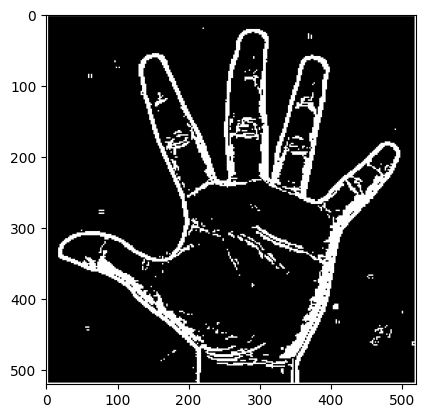

In [123]:
tangan_resize2 = resize(tangan_threshold, 520, 520)
tangan_erosi2 = dilasi(tangan_resize2, kernel_x)
plt.imshow(tangan_resize2, cmap='gray')

## ANALISIS PERBANDINGAN SEBELUM DAN SETELAH MORFOLOGI 3 X 3
#### Sebelum Morfologi: Menampilkan citra asli dalam bentuk grayscale, kemudian diresize ukurannya menjadi 256 x 256. Setelah itu, dilakukan deteksi tepi menggunakan operator Sobel untuk mendeteksi tepi telapak tangan menjadi putih, sedangkan yang lainnya hitam. Terakhir, dilakukan thresholding untuk mengubah grayscale jadi biner hitam putih. Yang dari awal terlihat jelas telapak tangan menjadi sebuah citra hitam putih saja

#### Setelah Morfologi: Dilakukan tes pada hasil citra thresholding, tes yang dilakukan antara lain dilasi, erosi, opening, closing, thinning, thickening, dan gradient morfologi. Pada dilasi, terjadi perbesaran area objek pada citra biner sehingga hasil citra menebal. Pada Erosi, terjadi penipisan area objek pada citra biner sehingga hasil citra tipis dari citra thresholding. Pada Opening, terjadi proses menghilangkan noise kecil atau titik putih kecil di background sehingga banyak detail hilang. Pada Closing, terjadi proses menutup lubang kecil di dalam objek sehingga detail detail pada telapak tangan bergabung menjadi 1. Pada Thinning, terjadi penipisan citra hingga menjadi seperti kerangka skeleton. Pada Thickening, terjadi proses penebalan sehingga hasil citra menjadi sangat tebal. Pada Gradient Morfologi, menghasilkan tepi atau kontur objek dari citra biner.

## ANALISIS PERBANDINGAN MORFOLOGI 3 X 3 DENGAN 5 X 5
#### Pada Morfologi 3 X 3 hasil citranya masih terlihat pada masing masing operasi morfologinya

#### Pada Morfologi 5 X 5 hasil citranya mulai berkurang bahkan hilang pada bagian Erosi, Opening, dan Thinning. Pada operator Dilasi, Closing, Thickening, dan Gradient Morfologi semakin menebal

## ANALISIS KOMBINASI 2 PROSES MORFOLOGI
#### Terjadinya penghilangan tepi citra pada Opening + Closing. Pada Closing + Opening terjadinya penebalan. Pada Opening + Dilasi tepinya mulai hilang. Pada Closing + Erosi tepinya terjadi penipisan dan penebalan
